# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [1]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
# import os

# from dotenv import load_dotenv
# load_dotenv()

from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification

import configuration
from src import setup, data_utils, hf_utils
from src.models import bert

/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B. Data

### B.1. Load sets

In [3]:
data_frac = data_utils.DATA_FRACTION

df_train, df_val, df_test = data_utils.load_datasets()

### B.2. Shrink dataset size for development purpose

In [4]:
# Comment out this cell to use the full dataset. This is just for quick testing.
train_size = 100
val_size = int(train_size * len(df_val) / len(df_train))
test_size = int(train_size * len(df_test) / len(df_train))

df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)

In [5]:
# Load data as Hugging Face Datasets
ds_train, ds_val, ds_test = hf_utils.create_datasets(df_train, df_val, df_test)

## C. Tokenization

In [6]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [7]:
hf_utils.max_length_dist(df_train, 'tweet_text', tokenizer)

90th percentile: 48.5
95th percentile: 50.74999999999999
99th percentile: 52.55
Absolute Maximum length: 53


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [8]:
save_path = Path(f"../tokens/BERT/{data_frac}")
train_tokenized, val_tokenized, test_tokenized = hf_utils.load_or_tokenize(
    ds_train, ds_val, ds_test, tokenizer, save_path
    , force_retokenize=True, format_dataset=bert.format_dataset
)

Tokenizing datasets...


Map: 100%|██████████| 21/21 [00:00<00:00, 7294.44 examples/s]


Saving tokenized datasets to ../tokens/BERT/0.1...


Saving the dataset (1/1 shards): 100%|██████████| 21/21 [00:00<00:00, 3189.70 examples/s]


## D. Fine-tuning BERT
### D.1. Preparation

In [ ]:
device = setup.setup_device_with_seeds()

batch_size = 16
learning_rate = 5e-5
num_epochs = 5
patience = 2  # early stopping, if validation loss does not improve for this many epochs

train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
# Optimizer
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

Using device: mps


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [10]:
model, train_loss_history, val_loss_history, val_acc_history = bert.finetune(train_tokenized, val_tokenized, configs)

Starting BertForSequenceClassification fine-tuning...
Using device: mps
Number of training samples: 100
Number of validation samples: 21
Batch size: 16
Number of epochs: 5
Early stopping patience: 2 epochs
--------------------------------------------------


Validating Epoch 1/5: 100%|██████████| 2/2 [00:00<00:00,  2.97it/s]


Epoch 1/5 | Train Loss: 0.5821 | Val Loss: 0.4525 | Val Acc: 0.7143


Validating Epoch 2/5: 100%|██████████| 2/2 [00:00<00:00, 10.16it/s]


Epoch 2/5 | Train Loss: 0.5282 | Val Loss: 0.4143 | Val Acc: 0.7619


...

Epoch 3/5 | Train Loss: 0.2947 | Val Loss: 0.4278 | Val Acc: 0.7143


Validating Epoch 4/5: 100%|██████████| 2/2 [00:00<00:00, 10.10it/s]


Epoch 4/5 | Train Loss: 0.1562 | Val Loss: 0.3014 | Val Acc: 0.8571


Validating Epoch 5/5: 100%|██████████| 2/2 [00:00<00:00,  8.42it/s]


Epoch 5/5 | Train Loss: 0.0500 | Val Loss: 0.3267 | Val Acc: 0.8571
Loaded best model with Val Loss: 0.3014


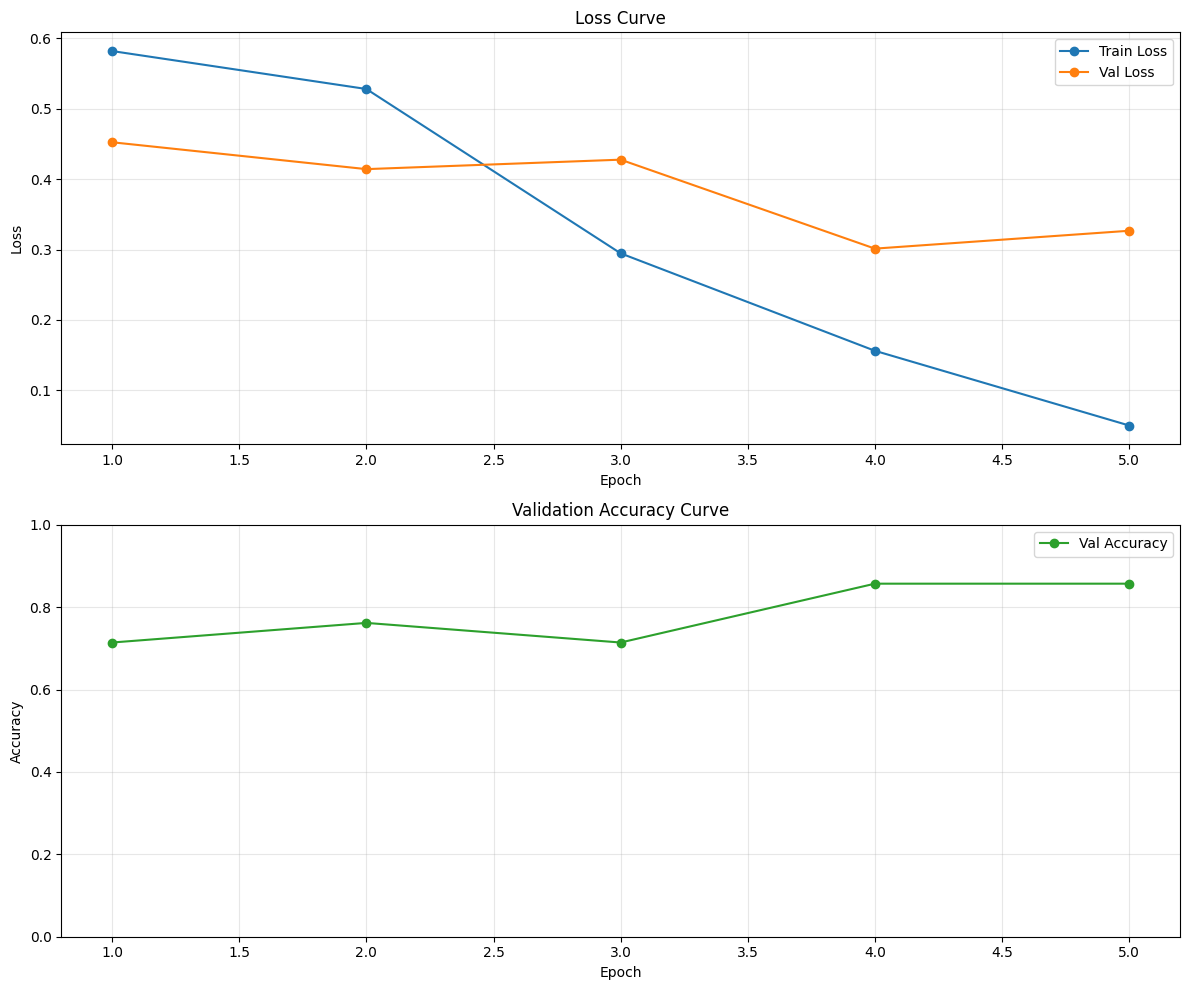

In [11]:
hf_utils.plot_fine_tune_history(train_loss_history, val_loss_history, val_acc_history)

### B.3. Predict on the Test set

In [12]:
predictions = bert.predict(model, test_tokenized, device)

Predicting on Test Set: 100%|██████████| 2/2 [00:00<00:00,  9.30it/s]


In [13]:
bert.report_metrics(test_tokenized, predictions)


Classification report:
              precision    recall  f1-score   support

       False     0.9474    1.0000    0.9730        18
        True     1.0000    0.6667    0.8000         3

    accuracy                         0.9524        21
   macro avg     0.9737    0.8333    0.8865        21
weighted avg     0.9549    0.9524    0.9483        21



In [14]:
hf_utils.group_report_metrics(df_test, predictions, group_by="subset", labels="informative")

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.8000    1.0000    0.8889         4
        True     1.0000    0.6667    0.8000         3

    accuracy                         0.8571         7
   macro avg     0.9000    0.8333    0.8444         7
weighted avg     0.8857    0.8571    0.8508         7

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    1.0000    1.0000         8

    accuracy                         1.0000         8
   macro avg     1.0000    1.0000    1.0000         8
weighted avg     1.0000    1.0000    1.0000         8

 Classification Report for Subset: weather
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    1.0000    1.0000         6

    a